In [1]:
2

2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


import scanpy as sc
import anndata as ad

from matplotlib.colors import rgb2hex
import seaborn as sns

import os
# BASE_DIR = '/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/20250901_092842XeniumHDCA_1024svg_n8/model/reference/'
# os.listdir(BASE_DIR)

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "niche_figure"
 
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                                   vector_friendly=True
                             )

In [3]:
PATH = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_XENIUM_HVGNUMBER1905__MAXEPOCHS20__BATCHKEYsample_id/adata_TUTORIAL_XENIUM+HVGNUMBER1905__MAXEPOCHS20__BATCHKEYsample_id_HSnichesv2.h5ad'
adata=sc.read_h5ad(PATH)

In [4]:
# md = adata.obs["niche19"].to_dict()

In [5]:
# # v2 version

# adata.obs["niche19"]=adata.obs.index.map(md)
# adata.write('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/adata_HSmappedV2.h5ad')

# adata.obs.niche19.value_counts()


In [6]:
2

2

In [7]:
# adata_hs.obs["niche19"]= adata_hs.obs.index.map(md2)

# adata_hs.obs["niche19"].value_counts()

In [8]:
#adata_hs = adata_hs[~adata_hs.obs["niche19"].isna()]
adata_hs=adata

subset = adata_hs.obs[adata_hs.obs["niche19"].str.startswith("Plasma")]
vc = subset["lvl5_annotation"].value_counts()
vc
vc_filtered = vc[vc >= 10]





adata_hs_p=adata_hs[(adata_hs.obs["provisional"].str.startswith("Plasma"))|
           (adata_hs.obs["lvl5_annotation"].str.startswith("Sweat"))|
              (adata_hs.obs["lvl5_annotation"].str.startswith("Bc"))
           ]
adata_hs_p=adata_hs_p[(adata_hs_p.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
              (adata_hs_p.obs["lvl5_annotation"].str.startswith("Bc"))|
           (adata_hs_p.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata_hs_p.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Plasma cell                       4253
Sweat gland                       3296
Sweat gland channel outer         2167
Sweat gland Myoepithelial         1754
Sweat gland channel inner         1086
F1: Superficial                    475
F4: DS_DPEP1+                      408
Mac2                               264
F2: Universal                      200
T                                  174
Bcell                              141
Pericyte1                           64
Tc1                                 38
F4: TNN+COCH+                       28
cDC2                                27
Mast cell                           25
Treg                                23
F6: Inflammatory myofibroblast      20
cDC1                                20
F2/3: Perivascular                  13
Name: count, dtype: int64

In [9]:
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA',
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA',
     'validation dataset': '#FAFAFA'

    
    }

In [10]:
# # import numpy as np
# # import pandas as pd

# # import matplotlib.pyplot as plt
# # import seaborn as sns


# # import scanpy as sc
# # import anndata as ad

# # from matplotlib.colors import rgb2hex
# # import seaborn as sns

# # import os
# # # BASE_DIR = '/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/20250901_092842XeniumHDCA_1024svg_n8/model/reference/'
# # # os.listdir(BASE_DIR)

# # import matplotlib
# # matplotlib.rcParams['pdf.fonttype'] = 42
# # matplotlib.rcParams['ps.fonttype'] = 42
# # #%matplotlib inline
# # sc.settings.figdir = "niche_figure"
 
# # sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
# #                                    vector_friendly=True
# #                              )
# import scanpy as sc
# import anndata as ad

# import rapids_singlecell as rsc
# import rmm
# import cupy as cp
# from rmm.allocators.cupy import rmm_cupy_allocator

# rmm.reinitialize(managed_memory=True, pool_allocator=False)
# cp.cuda.set_allocator(rmm_cupy_allocator)
# sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
#                                    vector_friendly=True
#                              )

In [11]:
adata

AnnData object with n_obs × n_vars = 175057 × 4994
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'dataset_id', 'lvl5_annotation', 'atlas_status', 'atlas_status_reynolds', 'Timepoint', 'info_id6', 'tech', 'scanvi_predictions2', 'lvl1_new', 'Site_status_binary2', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id_dir', 'patient_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'Mapping_status', 'scanvi_predictions', 'provisional', 'niche19'
    uns: 'neighbor_20', 'umap'
    obsm: 'X_scanvi', 'X_scvi', 'X_umap', 'spatial'
    obsp: 'neighbor_2

In [12]:
# NEIGHBOR=20
# # rsc.pp.neighbors(adata, use_rep = 'nichecompass_latent', metric = "euclidean", n_neighbors=NEIGHBOR,key_added=f"neighbor_{NEIGHBOR}")
# # rsc.tl.umap(adata, min_dist=0.1, neighbors_key =f"neighbor_{NEIGHBOR}" )
# latent_key = "neighbor_20"
# sc.pl.umap(
#         adata,
#         color=["niche19"],
#         legend_loc="on data",
#         s=1,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
#     palette=colors_new2,

# #     linewidth=0.1,
# #     edgecolor='grey',
    
#   #   palette=["#F2F2F2",   "#87CEEB",    ],
#    #     save="refmap_umap_refquery.pdf"

#     )

In [13]:
# sc.pl.umap(
#         adata,
#         color=["niche19"],
#         legend_loc="on data",
#         s=1,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
#     palette=colors_new2,
#     groups=["Plasma_cell_rich"]

# #     linewidth=0.1,
# #     edgecolor='grey',
    
#   #   palette=["#F2F2F2",   "#87CEEB",    ],
#    #     save="refmap_umap_refquery.pdf"

#     )

In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "nc_figures"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))


/tmp/ipykernel_985358/2402019412.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/software/cellgen/team298/ls34/cookiecutter/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


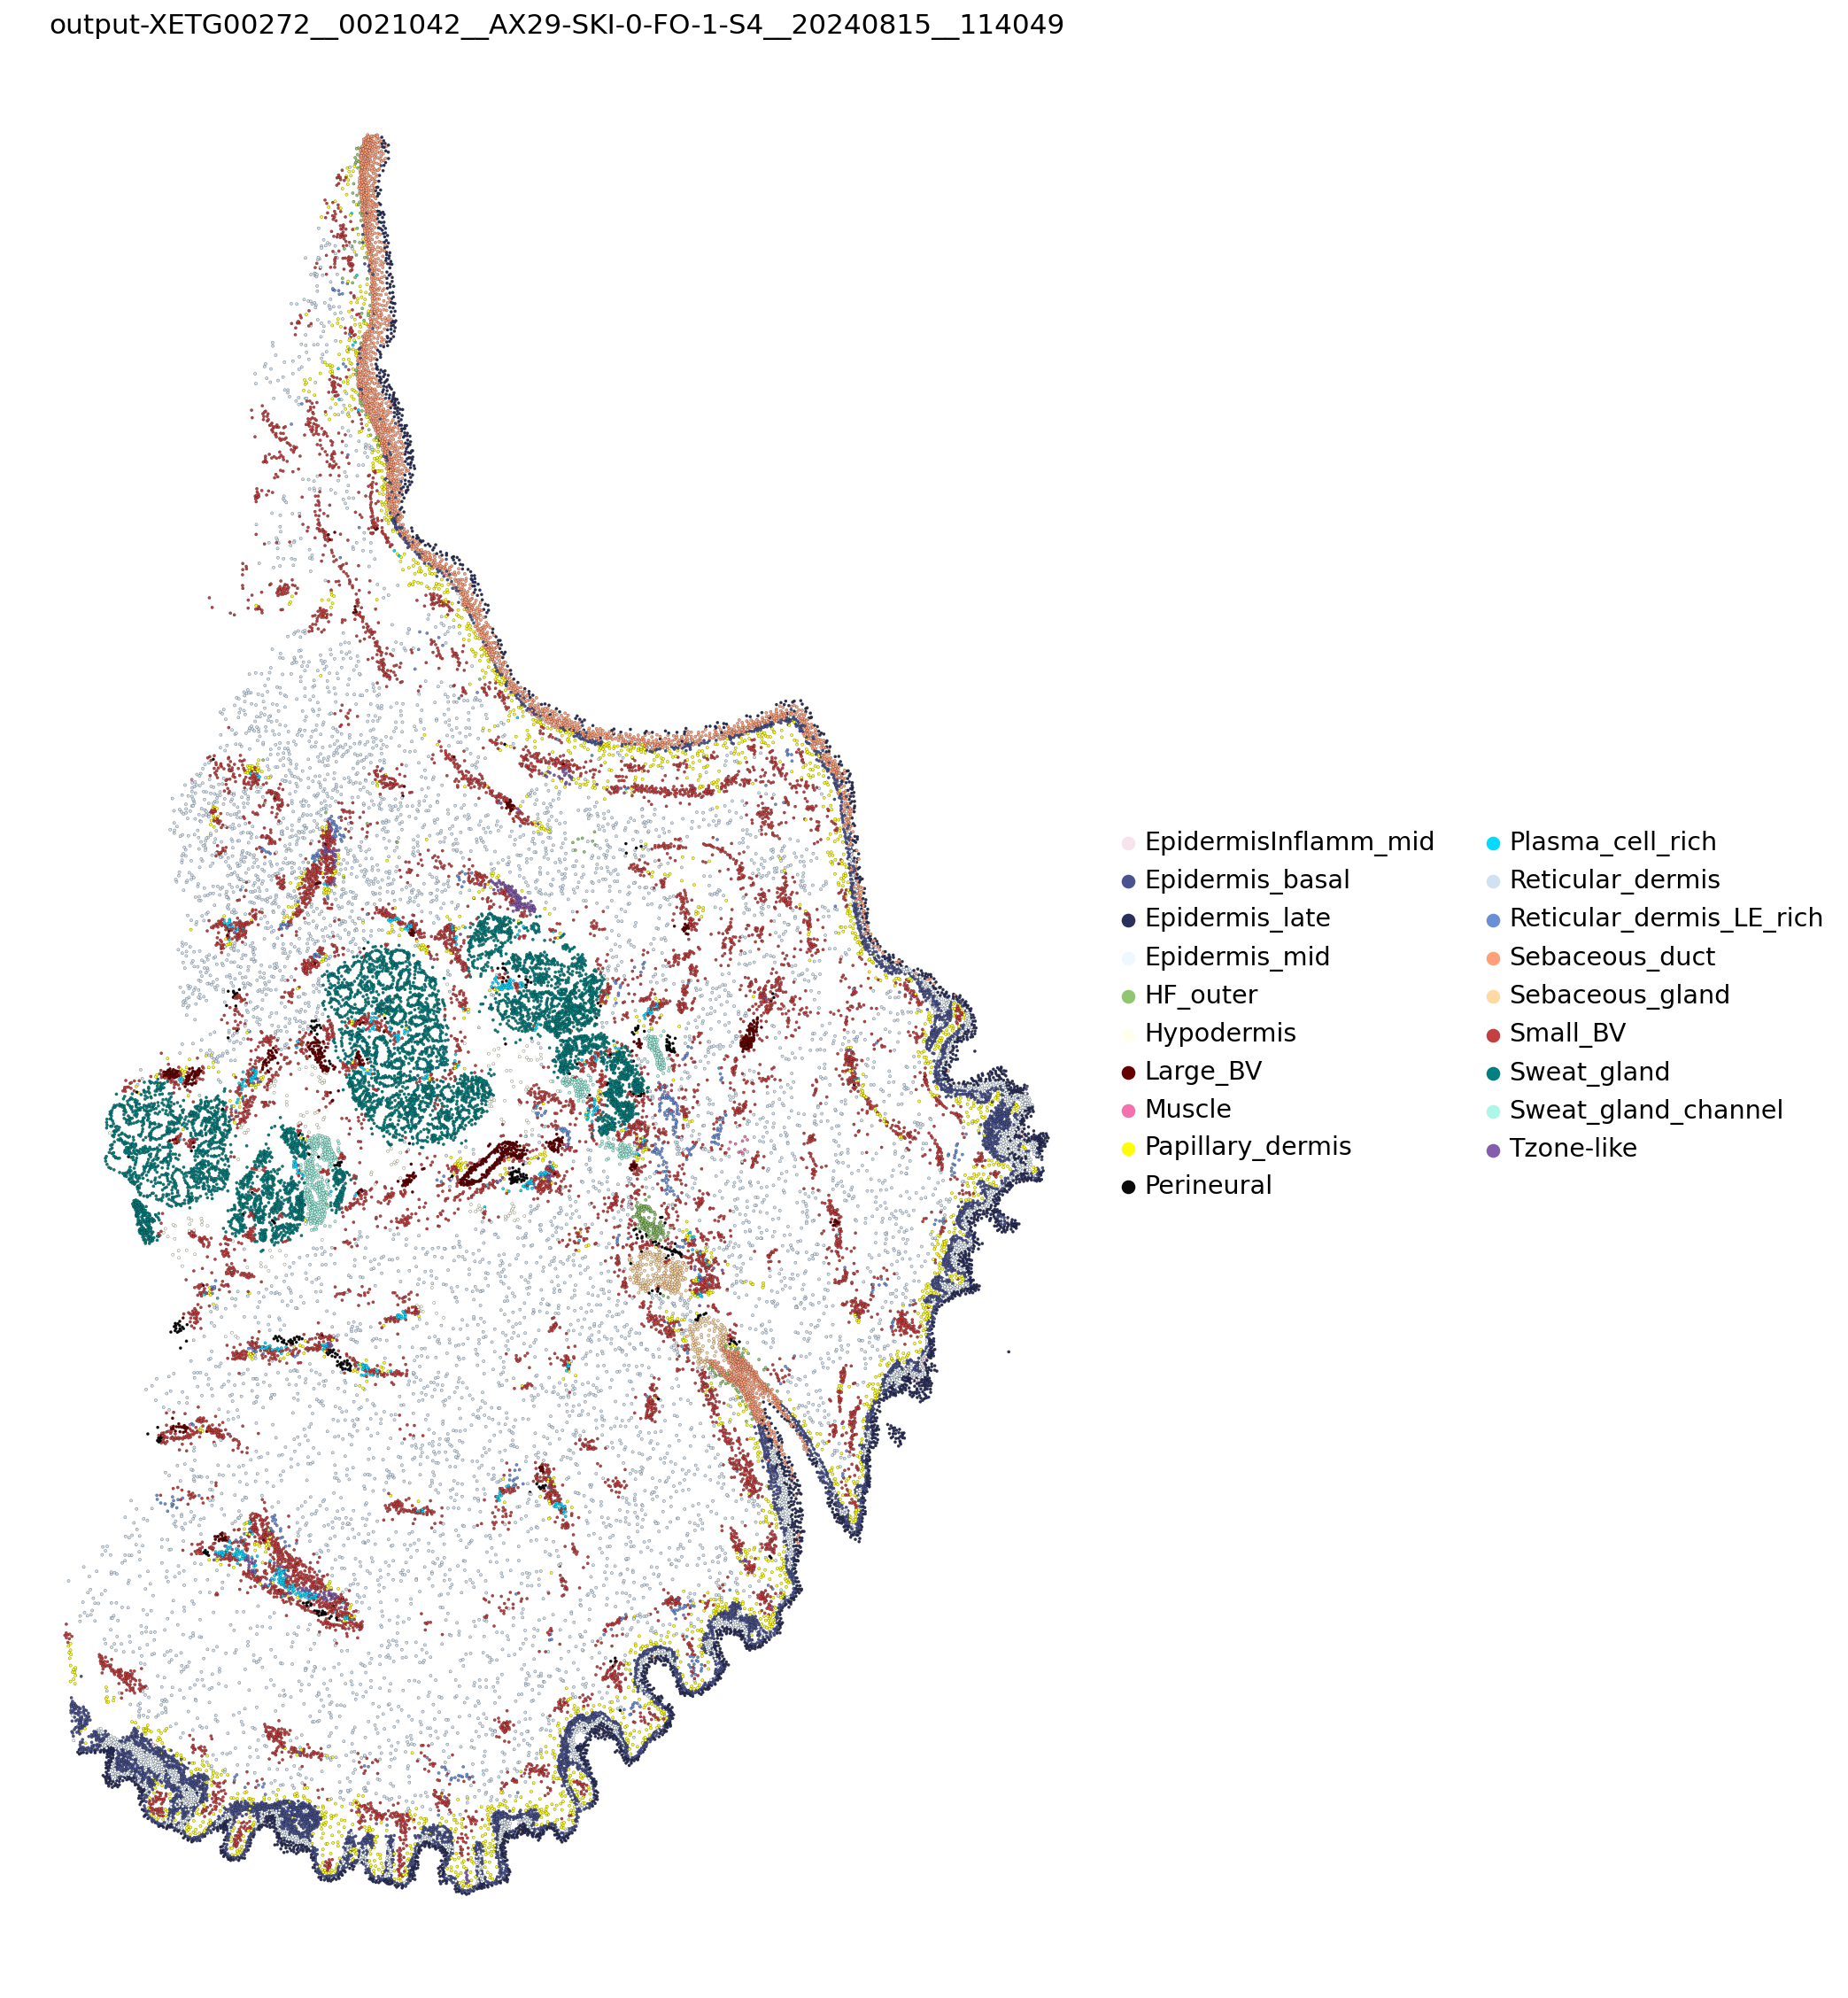

In [15]:
i=0
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in ['output-XETG00272__0021042__AX29-SKI-0-FO-1-S4__20240815__114049']:
    adata_i =  adata[adata.obs["sample_id"]==tissue_section_id] 
    sc.pl.spatial(
            adata_i,
            #library_id="spatial",
            #shape=None,
            color="provisional",
            spot_size=10,
            vmax=1,
        title=tissue_section_id,
           # title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
            #palette=custom_palette,
          #  save="perineural_mac_umap_NCIHE.pdf",
          edgecolor='black',
            linewidth=0.1 ,
        palette=colors_new2,
        save="HS_tissue_by_niche.pdf"
            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
          
      
      

In [16]:
KEEP = ['Sweat gland channel outer',
 'Sweat gland channel inner',
 'Sweat gland Myoepithelial',
 'Sweat gland',
'Plasma cell', 'Bcell',
        'Mac2_CCL14hi',
 'F2/3: Perivascular', 'F2/3: Perivascular', 'Mac2',]

/tmp/ipykernel_985358/3112045626.py:13: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/software/cellgen/team298/ls34/cookiecutter/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


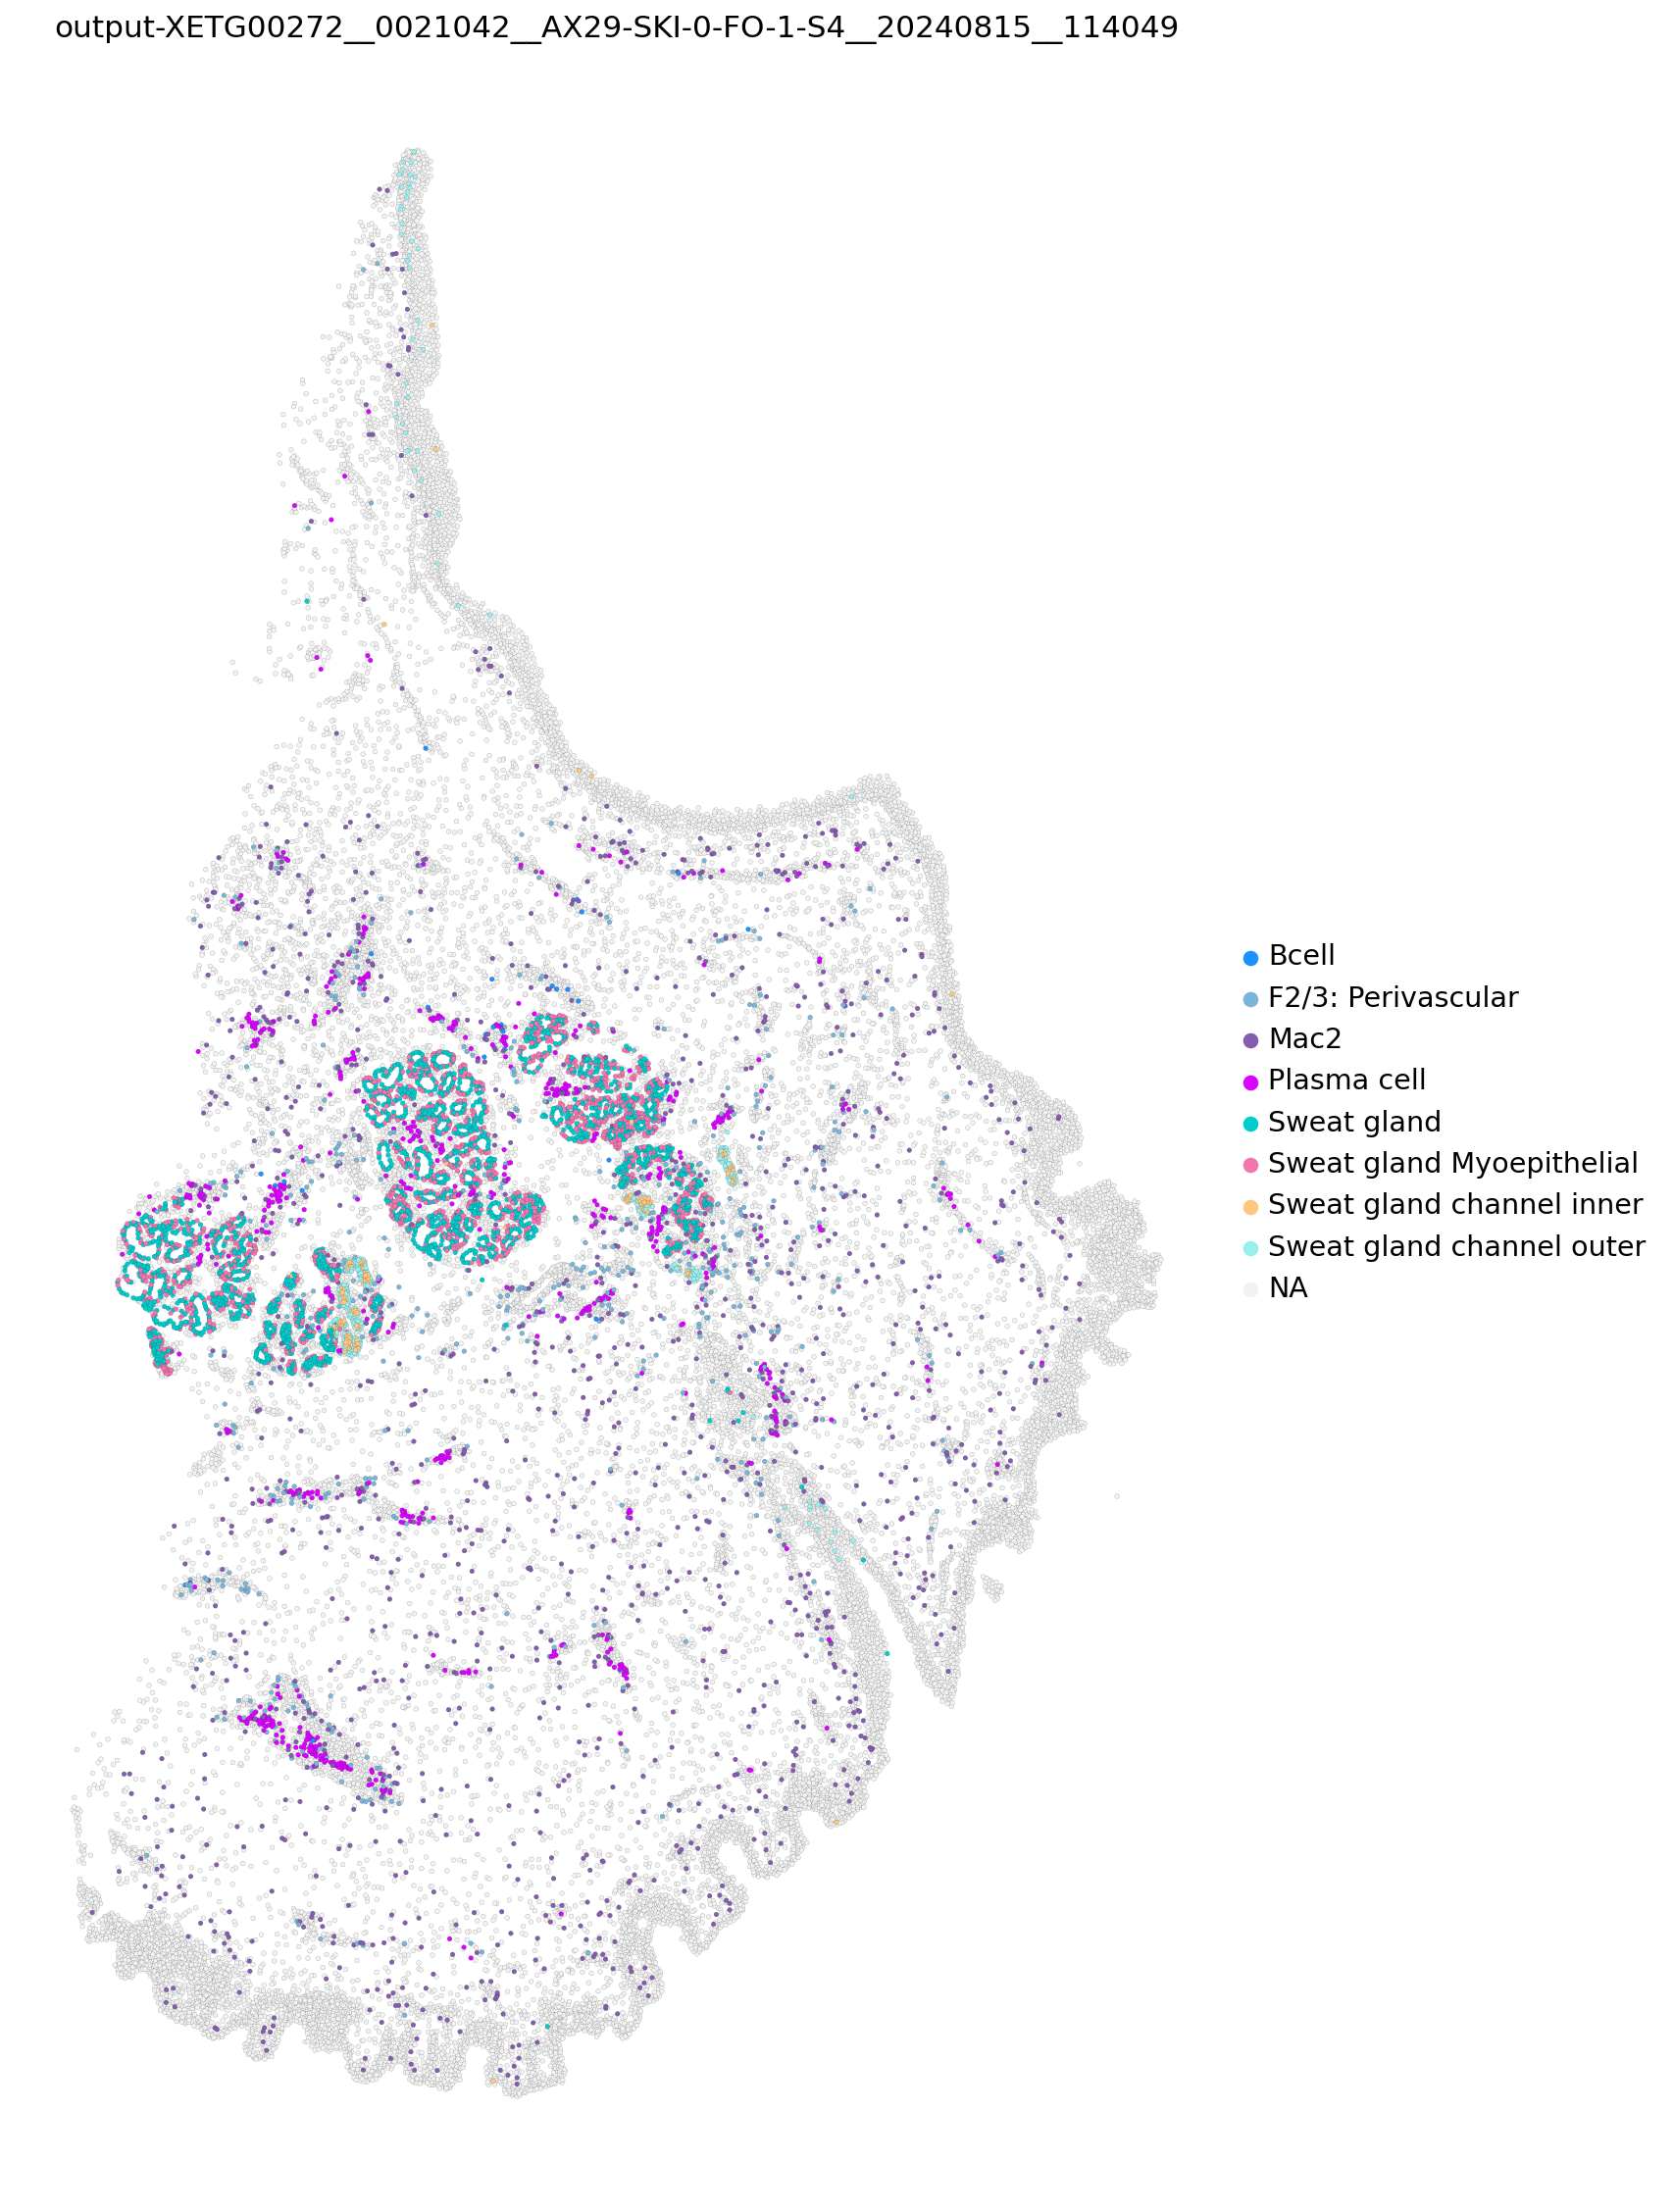

In [17]:
import pickle

file_path = "/nfs/team298/ls34/color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    colors = pickle.load(f)


i=0
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in ['output-XETG00272__0021042__AX29-SKI-0-FO-1-S4__20240815__114049']:
    adata_i =  adata[adata.obs["sample_id"]==tissue_section_id] 
    sc.pl.spatial(
            adata_i,
            #library_id="spatial",
            #shape=None,
            color="scanvi_predictions",
            spot_size=15,
            vmax=1,
        title=tissue_section_id,
           # title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
            #palette=custom_palette,
          #  save="perineural_mac_umap_NCIHE.pdf",
          edgecolor='black',
            linewidth=0.05 ,
        #palette=colors_new2,
        palette=colors,
        groups=KEEP,
        na_color="#F2F2F2",
        save="hs_celltypes.pdf"
            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
          
      

In [18]:
# Update fb annotation
import pickle

in_path = "/nfs/team298/ls34/dicts/fbs_hs.pkl"

with open(in_path, "rb") as f:
    md = pickle.load(f)
adata_hs.obs["tmp"]=adata_hs.obs.index.map(md)
adata_hs.obs["lvl5_annotation"]=adata_hs.obs["tmp"].fillna(adata_hs.obs["lvl5_annotation"])
adata_hs.obs["tmp"].value_counts()
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST


In [36]:
adata_hs.shape

(175057, 4994)

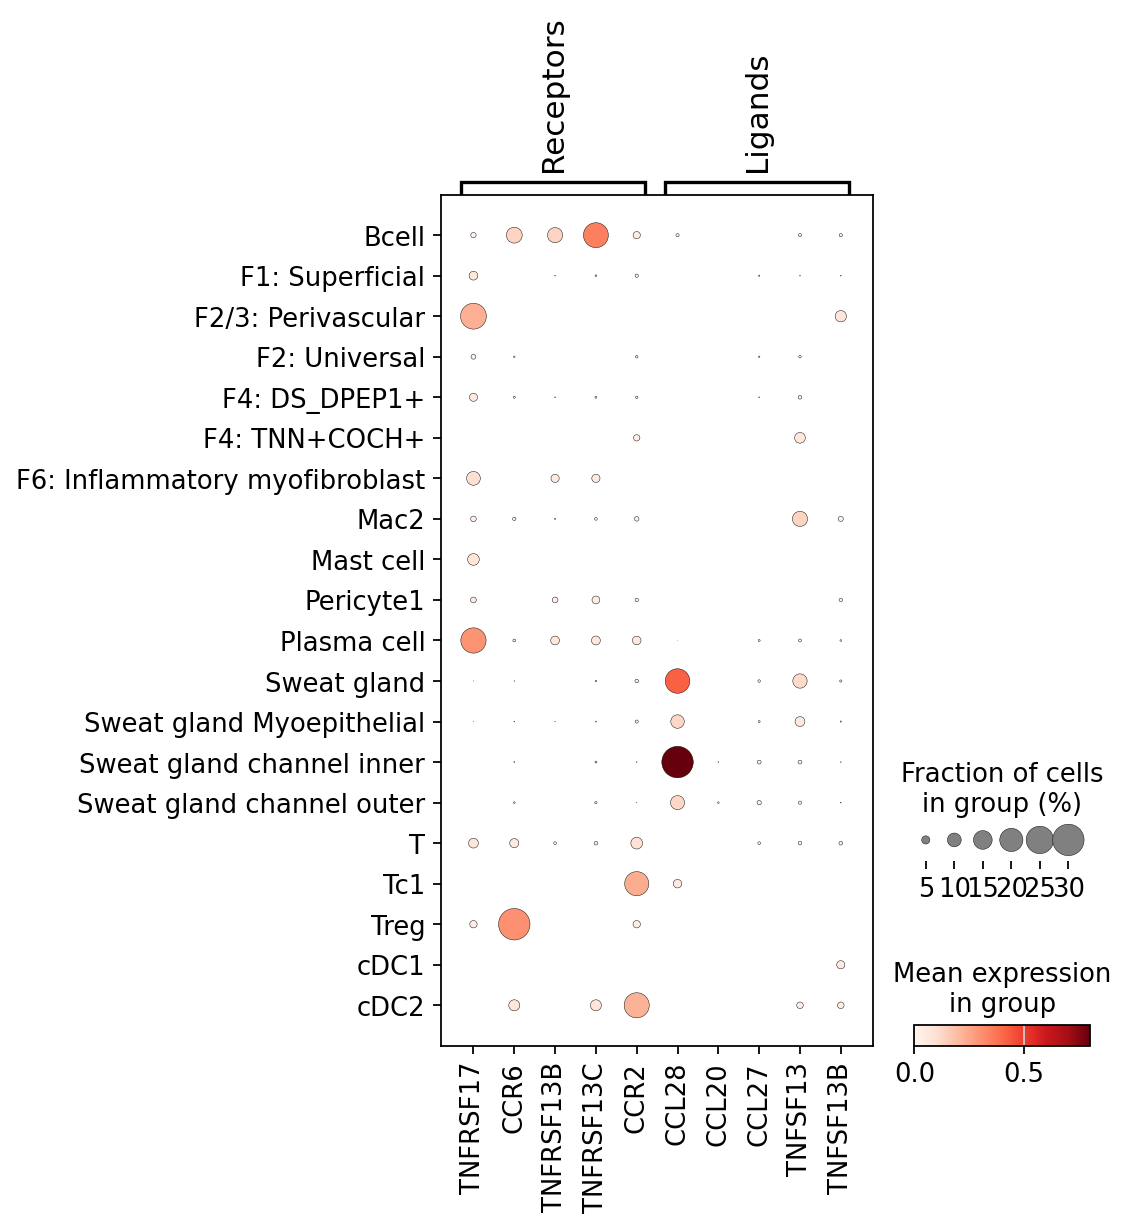

In [40]:

 
# ORDER = [


#  'Plasma cell',
#      "Bcell",
#  'Sweat gland Myoepithelial',
#          'Sweat gland',
#           'Sweat gland channel outer',
#  'Sweat gland channel inner',
#  'VE1_Art','VE3_Ven',
#  'VE4_Cap',
#     'Mac2',
#  'T',

#  'cDC1',
# 'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
#     # 'mSchwann',
#    # 'nmSchwann',
# ]
markers={
          "Receptors":  [ "CCR10", 'TNFRSF17', "CCR6",  'TNFRSF13B', 'TNFRSF13C', 
                        "CCR2",
                        ],

    "Ligands": [ "CCL28","CCL20",  "CCL27", "CCL2", 'TNFSF13', 'TNFSF13B'],
}
sc.pl.dotplot(
    adata_hs_p,
     remove_markers(markers),
    groupby="lvl5_annotation",
    vmax=0.8,
  #  categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
        dot_max=0.3,

    save='supp_HS_plasmacell_niche_signalling.pdf'
)



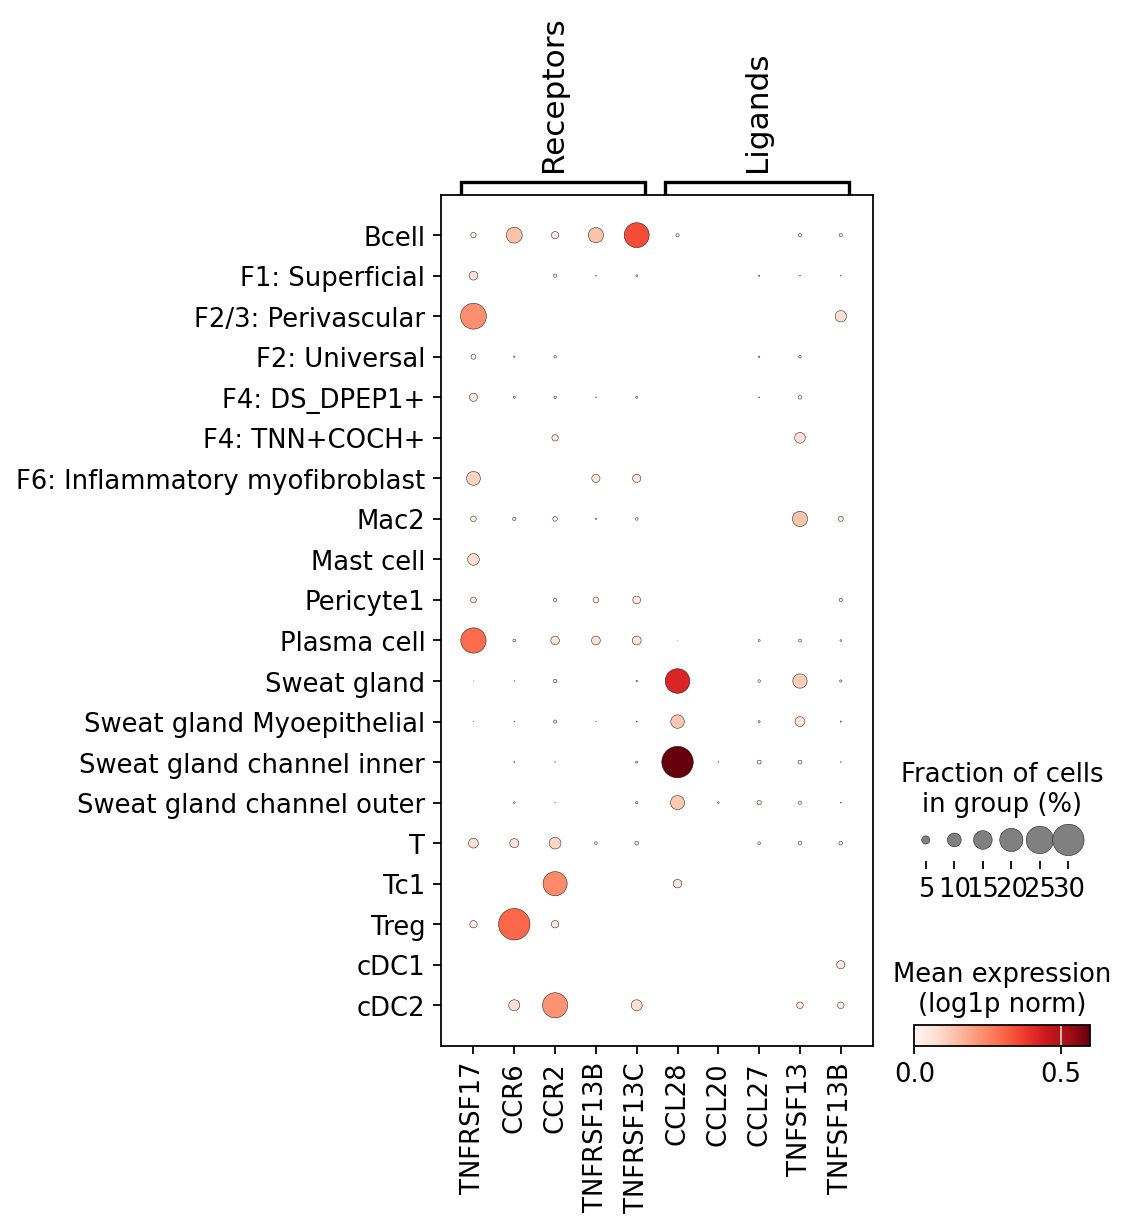

In [37]:
sc.pl.dotplot(
    adata_hs_p,
       remove_markers(markers),
    groupby="lvl5_annotation",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",

   save='supp_HS_plasmacell_niche_signallingreceptor.pdf'
)

 

In [42]:
ORDER=[ 'Plasma cell',
       'Bcell',
       
        'Sweat gland',
 'Sweat gland Myoepithelial',
 'Sweat gland channel inner',
 'Sweat gland channel outer',
# 'F1: Superficial',
 'F2/3: Perivascular',
 # 'F2: Universal',
 # 'F4: DS_DPEP1+',
 # 'F4: TNN+COCH+',
 # 'F6: Inflammatory myofibroblast',
 'Mac2',
 # 'Mast cell',
 # 'Pericyte1',


 'T',
 # 'Tc1',
 # 'Treg',
 # 'cDC1',
 # 'cDC2'
      ]

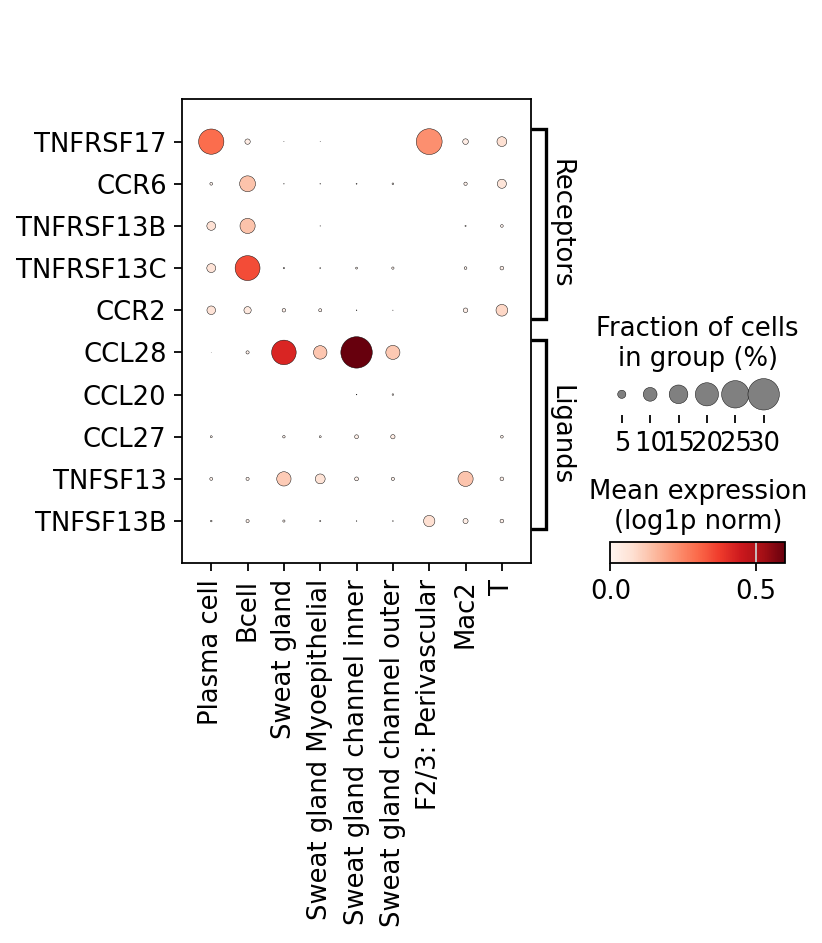

In [43]:
sc.pl.dotplot(
    adata_hs_p[adata_hs_p.obs["lvl5_annotation"].isin(ORDER)],
       remove_markers(markers),
    groupby="lvl5_annotation",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
swap_axes=True,
    categories_order=ORDER,
   save='supp_HS_plasmacell_niche_signallingreceptor_swapped.pdf'
)

 

In [26]:
sorted(adata_hs_p.obs.lvl5_annotation.unique())

['Bcell',
 'F1: Superficial',
 'F2/3: Perivascular',
 'F2: Universal',
 'F4: DS_DPEP1+',
 'F4: TNN+COCH+',
 'F6: Inflammatory myofibroblast',
 'Mac2',
 'Mast cell',
 'Pericyte1',
 'Plasma cell',
 'Sweat gland',
 'Sweat gland Myoepithelial',
 'Sweat gland channel inner',
 'Sweat gland channel outer',
 'T',
 'Tc1',
 'Treg',
 'cDC1',
 'cDC2']

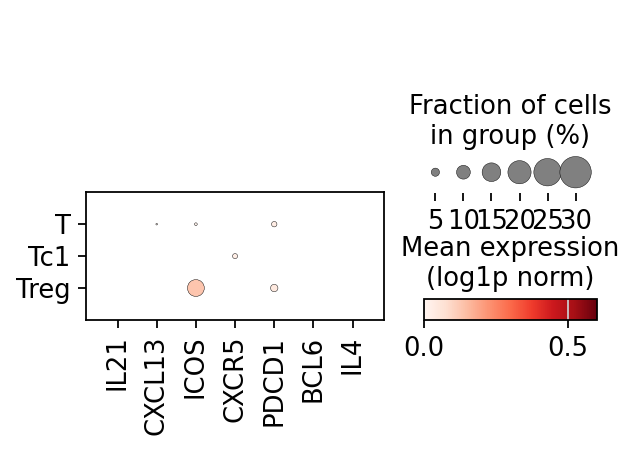

In [22]:
sc.pl.dotplot(
    adata_hs_p[adata_hs_p.obs["lvl5_annotation"].str.startswith("T")],
       remove_markers(['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', "IL4"
           ]),
    groupby="lvl5_annotation",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp_HS_Tfh.pdf'
)

 

/software/cellgen/team298/ls34/cookiecutter/lib/python3.11/site-packages/anndata/_core/anndata.py:1195: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


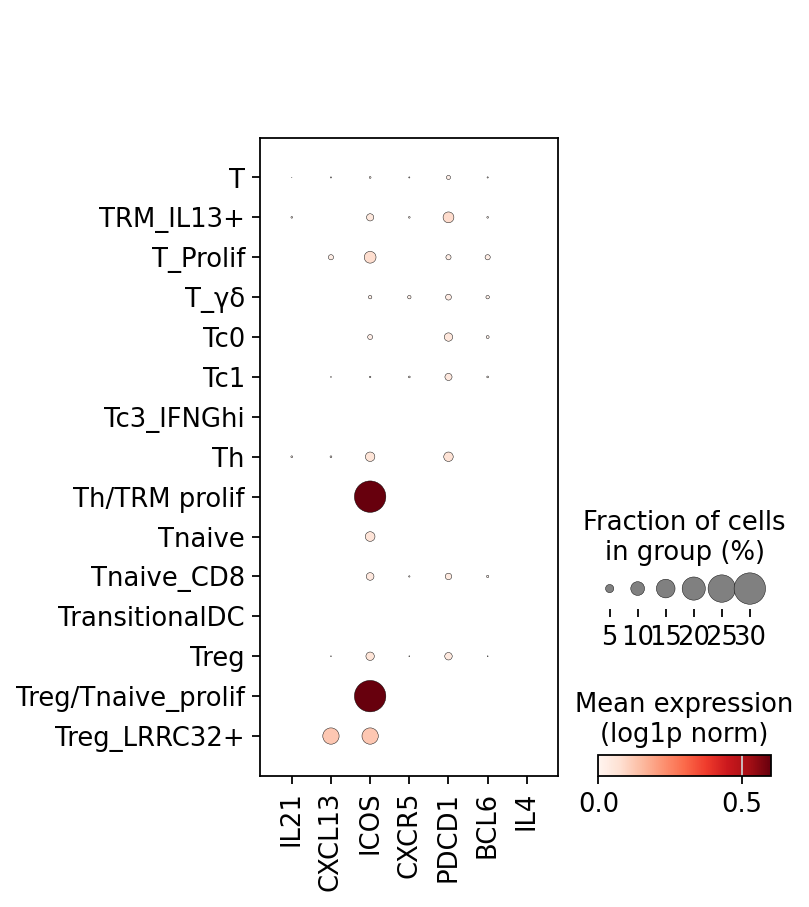

In [23]:
sc.pl.dotplot(
    adata_hs[adata_hs.obs["lvl5_annotation"].str.startswith("T")],
       remove_markers(['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', "IL4"
           ]),
    groupby="lvl5_annotation",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
 save='supp_HS_Tfh.pdf'
)

 

In [24]:
S

NameError: name 'S' is not defined

In [ ]:
import scanpy as sc
PATH = "/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_XENIUM_HVGNUMBER2001__MAXEPOCHS5__BATCHKEYsample_id__COVStech/adata_TUTORIAL_XENIUM+HVGNUMBER2001__MAXEPOCHS5__BATCHKEYsample_id__COVStech.h5ad"
adata_hs=sc.read_h5ad(PATH)


In [ ]:
adata_hs=adata_hs[adata_hs.obs["Mapping_status"]!="SpatialSkinAtlas"]

In [ ]:
[x for x in adata_hs.obs.scanvi_predictions.unique() if x.startswith("T")]

In [ ]:
sc.pl.dotplot(
    adata_hs[adata_hs.obs["scanvi_predictions"].str.startswith("T")],
       remove_markers(['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', "IL4", "ICA1"
           ]),
    groupby="scanvi_predictions",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
   # colorbar_title="Mean expression\n(log1p norm)",
# save='supp_HS_Tfh.pdf'
)

 

In [ ]:
# adata.write('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/adata_HSmappedV2.h5ad')


In [ ]:
stop

In [ ]:
sc.pl.dotplot(
    adata_hs[adata_hs.obs["lvl5_annotation"].str.startswith("T")],
       remove_markers(['IL21', "CXCL13", "ICOS", 'CXCR5', 'PDCD1', 'BCL6', "IL4"
           ]),
    groupby="lvl5_annotation",
    vmax=0.6,
    dot_max=0.3,
    #categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
   # save='supp_HS_plasmacell_niche_signallingreceptor.pdf'
)

 

In [ ]:
999

In [ ]:
adata_hs[adata_hs.obs["provisional"]=="Plasma_cell_rich"].obs.scanvi_predictions.value_counts()

In [ ]:
KEEP = ['Plasma cell',
 #'F1: Superficial',
 'Tc1',
 #'F4: DS_DPEP1+',
 #'F2: Universal',
 'Mac2',
 #'F4: TNN+COCH+',
 #'Th',
 #'Treg',
 'VE3_Ven',
 'Bcell',
 #'Pericyte1',
 #'MigDC (cDC2)',
 #'F3: FRC-like',
 #'Treg_LRRC32+',
 #'pDC',
 'cDC2',
 'cDC1',
 #'T_γδ',
 #'Mast cell',
 #'Mac2_CCL14hi',
 'F2/3: Perivascular',
 #'LE',
 #'F4: DP_HHIP+',
 'VE4_Cap',
 # 'Mac_CX3CR1+',
 # 'KC1',
 # 'Mac1',
 'Sweat gland',
 # 'KC2/3_cycling',
 # 'Tnaive_CD8',
 # 'VE1_Art',
 # 'F5: RAMP1+',
 # 'nmSchwann',
 # 'Pericyte2_VSMC',
 # 'Monocyte',
 # 'ILC1',
 # 'TRM_IL13+',
 # 'Neutrophil',
 #'F6: Inflammatory myofibroblast'
       ]

In [ ]:
list(adata_hs[adata_hs.obs["provisional"]=="Plasma_cell_rich"].obs.scanvi_predictions.unique())

In [ ]:
[x for x in adata.obs.scanvi_predictions.unique() if "sweat" in x.lower()]

In [ ]:
# for MODEL in runs:
#     print(MODEL)
#     try:
#         BASE=f'/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/{MODEL}/model/reference/'
#         adata=sc.read_h5ad(BASE  + '/adata.h5ad' )
#         #RENAME = {"nan":    'validation dataset'}
#         #adata.obs["tmp"]=adata.obs["niche19"].map(RENAME)
#         #adata.obs["niche19"]=adata.obs["tmp"].fillna(adata.obs["niche19"])
#         adata=adata[adata.obs["niche19"]!="nan"].copy()
#     #     sc.pl.umap(
#     #         adata,
#     #         color=["niche19"],
#     #         #legend_loc="on data",
#     #         s=1,
#     #         legend_fontsize=10,
#     #         legend_fontoutline=2,
#     #         show=True,
#     #         palette=colors_new2,
#     #             title=MODEL,

#     # #     linewidth=0.1,
#     # #     edgecolor='grey',

#     #   #   palette=["#F2F2F2",   "#87CEEB",    ],
#     #         save=f"nc_run_{MODEL}.pdf"

#     #     )
#         sc.pl.umap(
#             adata,
#             color=["niche19"],
#             legend_loc="on data",
#             s=2,
#             legend_fontsize=10,
#             legend_fontoutline=2,
#             show=True,
#         palette=colors_new2,
#                 title=MODEL,

#                     save=f"nc_run_{MODEL}_LEGENDON_biggerdots_novalidationdata.pdf"

#     #     linewidth=0.1,
#     #     edgecolor='grey',

#       #   palette=["#F2F2F2",   "#87CEEB",    ],
#        #     save="refmap_umap_refquery.pdf"

#         )
#         del(adata)
#         import gc
#         gc.collect()
#     except:
#         print("############")
#         print("failed with: ", MODEL)
#         print("############")


In [ ]:
8


In [ ]:
s

# INC VALIDATION DATASET

In [ ]:
for MODEL in runs:
    try:
        BASE=f'/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/{MODEL}/model/reference/'
        adata=sc.read_h5ad(BASE  + '/adata.h5ad' )
        RENAME = {"nan":    'validation dataset'}
        adata.obs["tmp"]=adata.obs["niche19"].map(RENAME)
        adata.obs["niche19"]=adata.obs["tmp"].fillna(adata.obs["niche19"])
    #     sc.pl.umap(
    #         adata,
    #         color=["niche19"],
    #         #legend_loc="on data",
    #         s=1,
    #         legend_fontsize=10,
    #         legend_fontoutline=2,
    #         show=True,
    #         palette=colors_new2,
    #             title=MODEL,

    # #     linewidth=0.1,
    # #     edgecolor='grey',

    #   #   palette=["#F2F2F2",   "#87CEEB",    ],
    #         save=f"nc_run_{MODEL}.pdf"

    #     )
        sc.pl.umap(
            adata,
            color=["niche19"],
            legend_loc="on data",
            s=0.5,
            legend_fontsize=10,
            legend_fontoutline=2,
            show=True,
        palette=colors_new2,
                title=MODEL,

                    save=f"nc_run_{MODEL}_LEGENDON.pdf"

    #     linewidth=0.1,
    #     edgecolor='grey',

      #   palette=["#F2F2F2",   "#87CEEB",    ],
       #     save="refmap_umap_refquery.pdf"

        )
        del(adata)
        import gc
        gc.collect()
    except:
        print("############")
        print("failed with: ", MODEL)
        print("############")


# INV VALIDATION DATASET

In [ ]:
for MODEL in runs:
    try:
        BASE=f'/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/{MODEL}/model/reference/'
        adata=sc.read_h5ad(BASE  + '/adata.h5ad' )
        RENAME = {"nan":    'validation dataset'}
        adata.obs["tmp"]=adata.obs["niche19"].map(RENAME)
        adata.obs["niche19"]=adata.obs["tmp"].fillna(adata.obs["niche19"])
    #     sc.pl.umap(
    #         adata,
    #         color=["niche19"],
    #         #legend_loc="on data",
    #         s=1,
    #         legend_fontsize=10,
    #         legend_fontoutline=2,
    #         show=True,
    #         palette=colors_new2,
    #             title=MODEL,

    # #     linewidth=0.1,
    # #     edgecolor='grey',

    #   #   palette=["#F2F2F2",   "#87CEEB",    ],
    #         save=f"nc_run_{MODEL}.pdf"

    #     )
        sc.pl.umap(
            adata,
            color=["niche19"],
            legend_loc="on data",
            s=2,
            legend_fontsize=10,
            legend_fontoutline=2,
            show=True,
        palette=colors_new2,
                title=MODEL,

                    save=f"nc_run_{MODEL}_LEGENDON_biggerdots.pdf"

    #     linewidth=0.1,
    #     edgecolor='grey',

      #   palette=["#F2F2F2",   "#87CEEB",    ],
       #     save="refmap_umap_refquery.pdf"

        )
        del(adata)
        import gc
        gc.collect()
    except:
        print("############")
        print("failed with: ", MODEL)
        print("############")


In [ ]:
1

In [ ]:
stop

In [ ]:
adata

In [ ]:
# sc.pl.umap(
#         adata,
#         color=["batch_nc"],
#         #legend_loc="on data",
#         s=5,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
# #     linewidth=0.1,
# #     edgecolor='grey',
    
#   #   palette=["#F2F2F2",   "#87CEEB",    ],
#    #     save="refmap_umap_refquery.pdf"

#     )

In [ ]:
sc.pl.umap(
        adata,
        color=["niche19"],
        #legend_loc="on data",
        s=5,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
    groups=["Sebaceous_immune", "Plasma_cell_rich"]
#     linewidth=0.1,
    
#     edgecolor='grey',
    
  #   palette=["#F2F2F2",   "#87CEEB",    ],
   #     save="refmap_umap_refquery.pdf"

    )

In [ ]:
# sc.pl.umap(
#         adata[adata.obs["batch_nc"]!="query"],
#         color=["niche19"],
#         #legend_loc="on data",
#         s=50,
#         legend_fontsize=10,
#         legend_fontoutline=2,
#         show=False,
# #     linewidth=0.1,
# #     edgecolor='grey',
    
#   #   palette=["#F2F2F2",   "#87CEEB",    ],
#    #     save="refmap_umap_refquery.pdf"

#     )

In [ ]:
# adata

In [ ]:
# 8

In [ ]:
rsc.pp.neighbors(adata,
                n_neighbors=20,
                use_rep='nichecompass_latent',
                key_added='neighborhood')
rsc.tl.umap(adata,
           neighbors_key='neighborhood',
          min_dist=0.1)





In [ ]:
# Set dataset params
emb_key = 'neighborhood'
latent_leiden_resolution = 3
latent_cluster_key = f'{emb_key}_emb_leiden_res{str(latent_leiden_resolution).replace(".", "_")}'


In [ ]:
adata

In [ ]:
rsc.tl.leiden(adata,
            neighbors_key=emb_key,
             key_added=latent_cluster_key,
             resolution=latent_leiden_resolution)


In [ ]:
sc.pl.umap(adata,
           # neighbors_key='neighborhood',
           color="latent_leiden_1",
          legend_loc="on data",
          )
sc.pl.umap(adata,
           # neighbors_key='neighborhood',
           color=latent_cluster_key,
          legend_loc="on data",
          )

In [ ]:
1

In [ ]:
# latent_cluster_key = f'{emb_key}_emb_leiden_res{str(latent_leiden_resolution).replace(".", "_")}'


In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                                   vector_friendly=True
                             )
sc.pl.umap(adata,
           # neighbors_key='neighborhood',
           color="niche19")

In [ ]:
adata

In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                                   vector_friendly=True
                             )
sc.pl.umap(adata,
           # neighbors_key='neighborhood',
           color="latent_leiden_1")

In [ ]:
RENAME = {}
GROUP = latent_cluster_key
#"latent_leiden_1" #"latent_leiden3"
ANNO_COL = "niche19"


In [ ]:

#adata_i = adata.copy()
for cluster in sorted(adata.obs[GROUP].unique()):
    # Subset the dataframe to that cluster
    #adata_i=adata_i[adata_i.obs["tech"]!="xenium"]
    #adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'fibroblast progenitors PDGFRA+']
    #adata_i=adata_i[adata_i.obs[ANNO_COL].str.lower()!=  'fibroblast progenitors PDGFRA+']
   # adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'FIBROBLAST PROGENITORS PDGFRA+']
    #adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'nan']

  #  adata_i=adata[adata_i.obs[ANNO_COL]!=  'reticulocyte']

    subset = adata.obs[adata.obs[GROUP] == cluster]
    # Count the values in combined_anno
    counts2 = subset[ANNO_COL].value_counts()
    
    # # Print top 3 contributors
    # print(f"Cluster {cluster} — Top 3 contributors:")
    # print(counts2.head(3), "\n")
    
    # Store the top contributor in RENAME
    if not counts2.empty:
        RENAME[cluster] = counts2.index[0]


        
adata.obs["provisional"]=adata.obs[GROUP].map(RENAME)
sc.pl.umap(
    adata,#[adata.obs["new_;ab"].isin(counts[counts >= 30].index)],
    color=[
         "provisional",  ANNO_COL
    ],
    legend_loc="on data",
    s=100, #neighbors_key="n",
    legend_fontsize=17,
    legend_fontoutline=2,
    # frame_on=False
 
)


In [ ]:
[x for x in adata.obs["info_id6"].unique() if "day" in x.lower()]

In [ ]:
# colors_new2 = {'Papillary_dermis': '#f2e2a2',
#  'Sweat_gland': "#5ed7cc",
#  'Sweat_gland_channel': '#afddd7',
#  'Muscle': '#c2eecc',
#  'Hypodermis': '#FFFFF0',
#  'Perineural': '#0A0A0A',
#  'Nonspecific': '#D3D3D3',
#  'Reticular_dermis': "#cbcfe6",#'#c2eecc',
#  'Large_BV': '#b9708b',
#  'Small_BV': '#c9456b',
#  'Tzone-like': '#845DAE',
#  'Sebaceous_gland': '#e79d2c',
#  'Sebaceous_immune': '#ff6145',
#  'Plasma_cell_niche': '#1F51FF',
#            'Epidermis_basal': '#033d9e',

#  'Epidermis_APChi': '#ff1493',
#  'Epidermis_late': '#2a2f5c',
#  'Epidermis_mid1': '#dcccce',
#  'Epidermis_mid2': '#FFFFFF',
#            'Epidermis_mid3': '#828ab7',

#  'Reticular_dermis_LE_rich': '#6A8ED8',
#  'Tzone-like_Theavy': '#B19CD9',
#  'Reticular dermis_F2/F3hi': '#35476C',
#  'Epidermis_basal_TRMhi': '#FF0000',
#  'HF_outer': '#828ab7',
#  'VenuleMuscle': '#FF69B4',
#  'Sebaceous_duct': '#FFA07A',
#  'VenuleEndothelium': '#8B0000',
#  'HF_inner': '#c2eecc',
#  'HF_Perifollicular': '#39FF14',
#  'Epidermis_basal_cycling': '#007cfe',
#  'Peri_sweat_gland': '#d9f9f7',
#  'HF_innermost': '#D95D54',
#  'Folded': '#D9D9D6',
# 'Sebaceous_inner_immune': '#F6A85C'}
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA',
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA'
    
    }

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche17'].cat.categories]
    
# sc.pl.umap(adata, 
#            color=["niche17"  ],
#            size=3, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=12,
#           legend_fontoutline=2,
#            linewidth=0.02,
#            edgecolor='white',
#           )
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))




for i,x in enumerate([ 'BK23_Day 3','BK23_Day 14' ]):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
    adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['niche19'].cat.categories]
    print(x)
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         #library_id="spatial",
#         #shape=None,
#         color="niche19",
#         spot_size=10,
#         vmax=1,
#         #title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#      legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#         title="",
#         #save="fig2_day14_by_niche_legend.pdf"

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="provisional",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.1,
                legend_fontsize=12,
        title="",
        palette=colors_new2,
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>30:
        break

In [ ]:
[x for x in adata.obs["info_id6"].unique() if "day 3" in x.lower()]

In [ ]:
SAMPLES= ['BK22_Day 3',
 'BK23_Day 3',
 'BK21_Day 3',
 'BK18_Day 3',
 'BK27_Day 3',
 'BK20_Day 3',
 'BK25_Day 3',
 'BK30_Day 3',
 'BK24_Day 3',
 'BK39_Day 3']
 


for i,x in enumerate( SAMPLES ):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
    adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['niche19'].cat.categories]
    print(x)
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         #library_id="spatial",
#         #shape=None,
#         color="niche19",
#         spot_size=10,
#         vmax=1,
#         #title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#      legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#         title="",
#         #save="fig2_day14_by_niche_legend.pdf"

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="provisional",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.3,
                legend_fontsize=12,
        title="",
        palette=colors_new2,
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>30:
        break

In [ ]:
SAMPLES=['BK23_Day 14',
 'BK22_Day 14',
 'BK27_Day 14',
 'BK20_Day 14',
 'BK21_Day 14',
 'BK18_Day 14',
 'BK25_Day 14',
 'BK24_Day 14',
 'BK39_Day 14',
 'BK30_Day 14']
 


for i,x in enumerate( SAMPLES ):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
    adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['niche19'].cat.categories]
    print(x)
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         #library_id="spatial",
#         #shape=None,
#         color="niche19",
#         spot_size=10,
#         vmax=1,
#         #title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#      legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#         title="",
#         #save="fig2_day14_by_niche_legend.pdf"

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="provisional",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.3,
                legend_fontsize=12,
        title="",
        palette=colors_new2,
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>30:
        break

In [ ]:
9

In [ ]:
# colors_new2 = {'Papillary_dermis': '#f2e2a2',
#  'Sweat_gland': "#5ed7cc",
#  'Sweat_gland_channel': '#afddd7',
#  'Muscle': '#c2eecc',
#  'Hypodermis': '#FFFFF0',
#  'Perineural': '#0A0A0A',
#  'Nonspecific': '#D3D3D3',
#  'Reticular_dermis': "#cbcfe6",#'#c2eecc',
#  'Large_BV': '#b9708b',
#  'Small_BV': '#c9456b',
#  'Tzone-like': '#845DAE',
#  'Sebaceous_gland': '#e79d2c',
#  'Sebaceous_immune': '#ff6145',
#  'Plasma_cell_niche': '#1F51FF',
#            'Epidermis_basal': '#033d9e',

#  'Epidermis_APChi': '#ff1493',
#  'Epidermis_late': '#2a2f5c',
#  'Epidermis_mid1': '#dcccce',
#  'Epidermis_mid2': '#FFFFFF',
#            'Epidermis_mid3': '#828ab7',

#  'Reticular_dermis_LE_rich': '#6A8ED8',
#  'Tzone-like_Theavy': '#B19CD9',
#  'Reticular dermis_F2/F3hi': '#35476C',
#  'Epidermis_basal_TRMhi': '#FF0000',
#  'HF_outer': '#828ab7',
#  'VenuleMuscle': '#FF69B4',
#  'Sebaceous_duct': '#FFA07A',
#  'VenuleEndothelium': '#8B0000',
#  'HF_inner': '#c2eecc',
#  'HF_Perifollicular': '#39FF14',
#  'Epidermis_basal_cycling': '#007cfe',
#  'Peri_sweat_gland': '#d9f9f7',
#  'HF_innermost': '#D95D54',
#  'Folded': '#D9D9D6',
#  'Sebaceous_inner_immune': '#F6A85C'}




# for i,x in enumerate(adata_query.obs.sample_id.unique()):
#     adata_i=adata[adata.obs["info_id6"]==x]
#     adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
#     adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_i.obs['niche19'].cat.categories]
#     print(x)
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         #library_id="spatial",
#         #shape=None,
#         color="niche19",
#         spot_size=10,
#         vmax=1,
#         #title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#      legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#         title="",
#         #save="fig2_day14_by_niche_legend.pdf"

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#         #library_id="spatial",
#         #shape=None,
#         color="provisional",
#         spot_size=10,
#         vmax=1,
#         #title=str(STATUS) + "_" + DONOR_ID,
#         #title=INFO_ID, #+ "_nonlesional",
#      legend_loc=None,
#         # legend_loc="on data",
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#         title="",
#          #save = f"fig1a_{x}_byniche_WITHLEGEND.pdf"
#         #save="fig2_day14_by_niche_legend.pdf"

#         #ax=ax,
#         #legend_loc="on data"  # Disable the legend for each subplot
#     )
#     if i>30:
#         break

In [ ]:
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA',
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA'
    
    }

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche17'].cat.categories]
    
# sc.pl.umap(adata, 
#            color=["niche17"  ],
#            size=3, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=12,
#           legend_fontoutline=2,
#            linewidth=0.02,
#            edgecolor='white',
#           )
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))


In [ ]:
adata[adata.obs["Timepoint"]=="nan"].obs.info_id6.value_counts()

In [ ]:
adata.obs["Timepoint"].value_counts()

In [ ]:
import gc
gc.collect()
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
adata_i = adata[~adata.obs["info_id6"].isin(KEEP)].copy()
adata_i=adata_i[adata_i.obs["Patient_status"]=="AD"].copy()
adata.obs.info_id6.value_counts()
adata_i=adata_i[adata_i.obs["Timepoint"]!="Day 14_HF"].copy()


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["provisional"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plota
fig, ax = plt.subplots(figsize=(10, 10))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of all cells")
ax.set_title("Starting treatment")

ax.legend(
    title="niche19",
    frameon=False
)

plt.tight_layout()
plt.show()

In [ ]:
adata[adata.obs["niche19"]=="Sebaceous_immune"].obs.info_id6.value_counts()


In [ ]:
adata[adata.obs["provisional"]=="Sebaceous_immune"].obs.info_id6.value_counts()

In [ ]:
stop

In [ ]:
PATH='/lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/20260204_203734BEACON_TIME_svg1024_neighbors8/model/reference//adata.h5ad.clustered'
adata=sc.read_h5ad(PATH)

In [ ]:
adata[adata.obs["provisional"]=="Sebaceous_immune"].obs.info_id6.value_counts()

In [ ]:
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA'
    }

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche17'].cat.categories]
    
# sc.pl.umap(adata, 
#            color=["niche17"  ],
#            size=3, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=12,
#           legend_fontoutline=2,
#            linewidth=0.02,
#            edgecolor='white',
#           )
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))


In [ ]:
sc.set_figure_params(
    dpi=50,
    dpi_save=300,
    figsize=(30, 30),
    facecolor='white',
    fontsize=7
)


i=0
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in adata[adata.obs["provisional"]=="Sebaceous_immune"].obs.info_id6.value_counts().index[:10]:
    adata_i =  adata[adata.obs["info_id6"]==tissue_section_id] 
    sc.pl.spatial(
            adata_i,
            #library_id="spatial",
            #shape=None,
            color="provisional",
            spot_size=10,
            vmax=1,
        title=tissue_section_id,
           # title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
            #palette=custom_palette,
          #  save="perineural_mac_umap_NCIHE.pdf",
          edgecolor='black',
            linewidth=0.2 ,
       # groups="TRM_IL13+",
        #cmap="Reds", 
        palette=colors_new2
            #ax=ax,
            #legend_loc="on data"  # Disable the legend for each subplot
        )
          
      
# adata.write(BASE  + '/adata.h5ad.clustered' )

In [ ]:
sc.pl.umap(
        adata[adata.obs["batch_nc"]=="query"],
        color=["niche19"],
        #legend_loc="on data",
        s=50,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
#     linewidth=0.1,
#     edgecolor='grey',
    
  #   palette=["#F2F2F2",   "#87CEEB",    ],
   #     save="refmap_umap_refquery.pdf"

    )

In [ ]:

adata_i = adata.copy()
for cluster in sorted(adata.obs[GROUP].unique()):
    # Subset the dataframe to that cluster
    #adata_i=adata_i[adata_i.obs["tech"]!="xenium"]
    #adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'fibroblast progenitors PDGFRA+']
    #adata_i=adata_i[adata_i.obs[ANNO_COL].str.lower()!=  'fibroblast progenitors PDGFRA+']
   # adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'FIBROBLAST PROGENITORS PDGFRA+']
    adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'nan']

    adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'reticulocyte']

    subset = adata_i.obs[adata_i.obs[GROUP] == cluster]
    # Count the values in combined_anno
    counts2 = subset[ANNO_COL].value_counts()
    
    # # Print top 3 contributors
    # print(f"Cluster {cluster} — Top 3 contributors:")
    # print(counts2.head(3), "\n")
    
    # Store the top contributor in RENAME
    if not counts2.empty:
        RENAME[cluster] = counts2.index[0]


        
adata.obs["provisional"]=adata.obs[GROUP].map(RENAME)
sc.pl.umap(
    adata,#[adata.obs["new_;ab"].isin(counts[counts >= 30].index)],
    color=[
         "provisional",  ANNO_COL
    ],
    legend_loc="on data",
    s=100, #neighbors_key="n",
    legend_fontsize=17,
    legend_fontoutline=2,
    # frame_on=False
 
)


In [ ]:
sc.pl.umap(
        adata[adata.obs["batch_nc"]!="query"],
        color=["niche19"],
        #legend_loc="on data",
        s=50,
        legend_fontsize=10,
        legend_fontoutline=2,
        show=False,
#     linewidth=0.1,
#     edgecolor='grey',
    
  #   palette=["#F2F2F2",   "#87CEEB",    ],
   #     save="refmap_umap_refquery.pdf"

    )

In [ ]:
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
adata_i = adata[~adata.obs["info_id6"].isin(KEEP)].copy()
adata_i=adata_i[adata_i.obs["Patient_status"]=="AD"].copy()
adata.obs.info_id6.value_counts()
adata_i=adata_i[adata_i.obs["Timepoint"]!="Day 14_HF"].copy()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Copy obs
obs = adata_i.obs.copy()

# Ensure categorical
obs["Timepoint"] = obs["Timepoint"].astype("category")
obs["niche19"] = obs["niche19"].astype("category")

NICHES = ["Sebaceous_immune", "Plasma_cell_rich"]

# Full contingency table
ct_all = pd.crosstab(obs["Timepoint"], obs["niche19"])

# Subset columns of interest
ct_sub = ct_all[NICHES]

# Normalize by ALL cells per timepoint
ct_prop = ct_sub.div(ct_all.sum(axis=1), axis=0)

# Colors
colors = [colors_new2[n] for n in ct_prop.columns]

# Plot
fig, ax = plt.subplots(figsize=(3, 4))

ct_prop.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of all cells")
ax.set_title("Starting treatment")

ax.legend(
    title="niche19",
    frameon=False
)

plt.tight_layout()
plt.show()

In [ ]:
0

In [ ]:
# import scanpy as sc
# import rapids_singlecell as rsc
# import rmm
# import cupy as cp
# from rmm.allocators.cupy import rmm_cupy_allocator
 
# rmm.reinitialize(managed_memory=True, pool_allocator=False)
# cp.cuda.set_allocator(rmm_cupy_allocator)


In [ ]:
adata

In [ ]:
NEIGHBOR=20
sc.pp.neighbors(adata, use_rep = 'nichecompass_latent', metric = "euclidean", n_neighbors=NEIGHBOR,key_added=f"neighbor_{NEIGHBOR}")
sc.tl.umap(adata, min_dist=0.1, neighbors_key =f"neighbor_{NEIGHBOR}" )
latent_key = "neighbor_20"
# sc.tl.leiden(adata, resolution=2, key_added="latent_leiden2", #neighbors_key= latent_key 
#              )
import pickle

In [ ]:
md = adata.obs["latent_leiden2"].to_dict()

del(adata)
import gc
gc.collect()



In [ ]:
import os
BASE='//lustre/scratch124/cellgen/haniffa/projects/developmental_fibroblasts/nobackup_output/nichecompasss/nichecompass/artifacts/spatial_reference_mapping/20260116_114135XeniumMINTFLOWDATA__REFQ/model/'

os.listdir(BASE)
adata=sc.read_h5ad(BASE + 'reference_query' +'/adata.h5ad' )

In [ ]:
adata.obs['latent_leiden2']=adata.obs.index.map(md)

In [ ]:
RENAME = {}
GROUP = "latent_leiden2"
ANNO_COL = "niche19"

adata_i = adata.copy()
for cluster in sorted(adata.obs[GROUP].unique()):
    # Subset the dataframe to that cluster
    #adata_i=adata_i[adata_i.obs["tech"]!="xenium"]
    #adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'fibroblast progenitors PDGFRA+']
    #adata_i=adata_i[adata_i.obs[ANNO_COL].str.lower()!=  'fibroblast progenitors PDGFRA+']
   # adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'FIBROBLAST PROGENITORS PDGFRA+']
    adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'nan']

    adata_i=adata_i[adata_i.obs[ANNO_COL]!=  'reticulocyte']

    subset = adata_i.obs[adata_i.obs[GROUP] == cluster]
    # Count the values in combined_anno
    counts2 = subset[ANNO_COL].value_counts()
    
    # # Print top 3 contributors
    # print(f"Cluster {cluster} — Top 3 contributors:")
    # print(counts2.head(3), "\n")
    
    # Store the top contributor in RENAME
    if not counts2.empty:
        RENAME[cluster] = counts2.index[0]


        
adata.obs["provisional"]=adata.obs[GROUP].map(RENAME)
sc.pl.umap(
    adata,#[adata.obs["new_;ab"].isin(counts[counts >= 30].index)],
    color=[
         "provisional",  ANNO_COL
    ],
    legend_loc="on data",
    s=100, #neighbors_key="n",
    legend_fontsize=17,
    legend_fontoutline=2,
    # frame_on=False
 
)


In [ ]:
adata.obs.batch_nc.value_counts()

In [ ]:
adata_query = adata[adata.obs["batch_nc"]=="query"].copy()

In [ ]:
colors_new2 = {'Papillary_dermis': '#f2e2a2',
 'Sweat_gland': "#5ed7cc",
 'Sweat_gland_channel': '#afddd7',
 'Muscle': '#c2eecc',
 'Hypodermis': '#FFFFF0',
 'Perineural': '#0A0A0A',
 'Nonspecific': '#D3D3D3',
 'Reticular_dermis': "#cbcfe6",#'#c2eecc',
 'Large_BV': '#b9708b',
 'Small_BV': '#c9456b',
 'Tzone-like': '#845DAE',
 'Sebaceous_gland': '#e79d2c',
 'Sebaceous_immune': '#ff6145',
 'Plasma_cell_niche': '#1F51FF',
           'Epidermis_basal': '#033d9e',

 'Epidermis_APChi': '#ff1493',
 'Epidermis_late': '#2a2f5c',
 'Epidermis_mid1': '#dcccce',
 'Epidermis_mid2': '#FFFFFF',
           'Epidermis_mid3': '#828ab7',

 'Reticular_dermis_LE_rich': '#6A8ED8',
 'Tzone-like_Theavy': '#B19CD9',
 'Reticular dermis_F2/F3hi': '#35476C',
 'Epidermis_basal_TRMhi': '#FF0000',
 'HF_outer': '#828ab7',
 'VenuleMuscle': '#FF69B4',
 'Sebaceous_duct': '#FFA07A',
 'VenuleEndothelium': '#8B0000',
 'HF_inner': '#c2eecc',
 'HF_Perifollicular': '#39FF14',
 'Epidermis_basal_cycling': '#007cfe',
 'Peri_sweat_gland': '#d9f9f7',
 'HF_innermost': '#D95D54',
 'Folded': '#D9D9D6',
 'Sebaceous_inner_immune': '#F6A85C'}




for i,x in enumerate(adata_query.obs.sample_id.unique()):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
    adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['niche19'].cat.categories]
    print(x)
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="niche19",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.05,
                legend_fontsize=12,
        title="",
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="provisional",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.05,
                legend_fontsize=12,
        title="",
         save = f"fig1a_{x}_byniche_WITHLEGEND.pdf"
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>30:
        break